In [28]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [2]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6


In [3]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [4]:
EX = N_EX / gamma
EY = N_EY / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [5]:
deltaP_P = 1.5e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.0015


In [6]:
from elements import TECA

# TECA DEFINITION



TECA = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 174e-6 ,
    side="left",
    lattice="strip",
    jaw = - 52.4e-3,
    tilt = - 1.23e-3,
    width = 1.8e-3,
    height = 50e-3
    )

TECS = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 174e-6 ,
    side="left",
    lattice="strip",
    jaw = -0.0315,
    tilt = 10e-6,
    width = 2e-3,
    height = 50e-3
    )

# Given values
x_teca = TECA.jaw  
delta_x_teca_prime = TECA.tilt + TECA.bending_angle 

In [7]:
def match_tunes(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['kqf', 'kqd'], step=1e-7),   # Varying quadrupole focal strengths
            xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4),   # Varying phase values
        ],
        targets=[
            xt.TargetSet(qx=qx, qy=qy, tol=1e-5),# Desired target tunes
            #xt.TargetSet(dqx=-1 * qx, dqy=0.47 * qy, tol=1e-3),   # Desired target chromaticities
        ])
    return opt

In [8]:
def match_chromaticity(line, qx, qy):
    # Extraction tunes
    opt = line.match(solve=False,
                     method='4d',
        vary=[
            xt.VaryList(['klsfa', 'klsda', 'klsdb', 'klsfb'], step=1e-7),   # Varying setupoles strengths ,  klsfa, klsda, klsfb, klsdb????
        ],
        targets=[
            xt.TargetSet(dqx=-1 * int(qx), dqy = 0.47 * int(qy), tol=1e-3),   # Desired target chromaticities
        ])
    return opt

# Importing line with Q22 optics


In [9]:
from elements import install_septa
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
#line.insert_element("TECS.everest_crystal", TECS, at_s = line.get_table()['s', 'tecs.21602'] )

line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)

teca_entry_s = line.get_table()['s', 'TECA.entry']


septa_names_with_apertures = install_septa(line, install_zs=False)
line.cycle("TECA.entry", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

<Line  at 4853038672>

In order to enable the tracking, it's needed to open the apertures

In [10]:
# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitEllipse
    if isinstance(element, xt.LimitEllipse):
        print(f"Element Name: {element_name}, Element: {element}")
        element.a = 1
        element.b = 1
        
# Iterate through all elements in the line
for element_name, element in line.element_dict.items():
    # Check if the element is of type LimitRect
    if isinstance(element, xt.LimitRect):
        print(f"Element Name: {element_name}, Element: {element}")
        element.min_x = -1
        element.max_x = 1

Element Name: qe.11402_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qd.11710_aper, Element: LimitEllipse(a=0.0415, b=0.0415)
Element Name: qf.11810_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qfa.21610_aper, Element: LimitEllipse(a=0.106, b=0.0203)
Element Name: qfa.21810_aper, Element: LimitEllipse(a=0.106, b=0.0203)
Element Name: qe.30202_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qecd.30602_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: qecd.31402_aper, Element: LimitEllipse(a=0.076, b=0.0192)
Element Name: ap.up.vvsb_aper, Element: LimitEllipse(a=0.156, b=0.156)
Element Name: ap.do.vvsb_aper, Element: LimitEllipse(a=0.156, b=0.156)
Element Name: ap.up.coldex_aper, Element: LimitEllipse(a=0.0335, b=0.0335)
Element Name: ap.do.coldex_aper, Element: LimitEllipse(a=0.0335, b=0.0335)
Element Name: qfa.41810_aper, Element: LimitEllipse(a=0.106, b=0.0203)
Element Name: qe.50202_aper, Element: LimitEllipse(a=0.076, b=0.0192)


In [11]:
tw_init = line.twiss(method='4d')
print(tw_init.qx)
print(tw_init.qy)

tw0 = tw_init.to_pandas()
tw0.index = tw0.name  

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
22.13000000010263
22.180000000010537


In [12]:
betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) * 1e3
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2) * 1e3
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} mm")
print(f"sigma_y max = {tw0.sy_mm.max()} mm")

D term / B term = 3.31
sigma_x max = 10.468444863433009 mm
sigma_y max = 1.1036200168346404 mm


In [13]:
# DISPERSION AND BETX AT THE TECA LOCATION
betx_teca = tw0.loc['TECA.entry'].betx
dx_teca = tw0.loc['TECA.entry'].dx

# COMPUTING THE BEAM SIZE 
tw0['sx_mm'] = np.sqrt(tw0['betx'] * EX + (tw0['dx'] * deltaP_P)**2) 
tw0['sy_mm'] = np.sqrt(tw0['bety'] * EY + (tw0['dy'] * deltaP_P)**2)
    
B_term0 = betx_teca * EX
D_term0 = (dx_teca * deltaP_P)**2
ratio0 = D_term0 / B_term0

sigma_xMAXQ22 = tw0.sx_mm.max()
sigma_yMAXQ22 = tw0.sy_mm.max()


print(f'D term / B term = {ratio0:.2f}')
print(f"sigma_x max = {tw0.sx_mm.max()} m")
print(f"sigma_y max = {tw0.sy_mm.max()} m")

D term / B term = 3.31
sigma_x max = 0.010468444863433008 m
sigma_y max = 0.0011036200168346405 m


In [14]:
mu_x_teca = tw0.loc['TECA.entry'].mux
mu_x_tpst = tw0.loc['tpst.21760_entry'].mux
mu_x_tcsm = tw0.loc['tcsm.51932.'].mux

phaseAdvanceTecaTpst = mu_x_tpst - mu_x_teca
phaseAdvanceTecaTcsm = mu_x_tcsm - mu_x_teca
phaseAdvanceTpstTcsm = mu_x_tcsm - mu_x_tpst

print(f"Phase advance Teca - Tpst: {phaseAdvanceTecaTpst:.2f}")
print(f"Phase advance Teca - Tcsm: {phaseAdvanceTecaTcsm:.2f}")
print(f"Phase advance Tpst - Tcsm: {phaseAdvanceTpstTcsm:.2f}")

Phase advance Teca - Tpst: 14.74
Phase advance Teca - Tcsm: 3.83
Phase advance Tpst - Tcsm: -10.91


In [15]:
# Get the positions of the TECA and COLLIMATORS markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']
tcsm_position = line.get_table()['s', 'tcsm.51932.']


In [16]:
# Define the range of tunes to inspect, avoiding integers and half-integers
#tune_range = [x / 10 for x in range(150, 270) if x % 10 != 0 and x % 10 != 5]   # from 15.0 to 25.9 for all decimals less than integers and half inegers
tune_range = [x / 100 for x in range(2240, 2340)]   # from 15.0 to 25.9 for all decimals

# Initialize an empty DataFrame to store Twiss parameters
twiss_df = pd.DataFrame()

In [17]:
print(tune_range)

[22.4, 22.41, 22.42, 22.43, 22.44, 22.45, 22.46, 22.47, 22.48, 22.49, 22.5, 22.51, 22.52, 22.53, 22.54, 22.55, 22.56, 22.57, 22.58, 22.59, 22.6, 22.61, 22.62, 22.63, 22.64, 22.65, 22.66, 22.67, 22.68, 22.69, 22.7, 22.71, 22.72, 22.73, 22.74, 22.75, 22.76, 22.77, 22.78, 22.79, 22.8, 22.81, 22.82, 22.83, 22.84, 22.85, 22.86, 22.87, 22.88, 22.89, 22.9, 22.91, 22.92, 22.93, 22.94, 22.95, 22.96, 22.97, 22.98, 22.99, 23.0, 23.01, 23.02, 23.03, 23.04, 23.05, 23.06, 23.07, 23.08, 23.09, 23.1, 23.11, 23.12, 23.13, 23.14, 23.15, 23.16, 23.17, 23.18, 23.19, 23.2, 23.21, 23.22, 23.23, 23.24, 23.25, 23.26, 23.27, 23.28, 23.29, 23.3, 23.31, 23.32, 23.33, 23.34, 23.35, 23.36, 23.37, 23.38, 23.39]


Computing the twiss parameters all over the tune range above defined

In [18]:

# Loop over the range of tunes
for tune in tune_range:
    
    
    # Set up the matching process with the current target tunes
    if tune % 1 == 0 or tune % 0.5 == 0:
        continue
    else:
        opt = match_tunes(line, tune, tune + 0.05)
    
    
    #opt = match_tunes(line, tune, tune + 0.05)
    opt.step(10)
    
    opt.target_status()
    opt.vary_status()    

    # Recalculate the Twiss parameters after setting the tunes
    tw = line.twiss(method='4d', x = TECA.jaw, px = TECA.tilt)
    tw = tw.to_pandas()
    tw_table = line.twiss(method='4d', x = TECA.jaw, px = TECA.tilt)
    
    tw.index = tw.name
    
    # COMPUTING

    # MAX BETAX ALONG THE RING
    max_betx = tw['betx'].max()
    min_betx = tw['betx'].min()
    # MAX DISPERSION ALONG THE RING
    max_dx = tw['dx'].max()
    min_dx = tw['dx'].min()
    # BIGGEST SIGMA_X ALONG THE RING
    #sigma_xMAX =  np.sqrt(max_betx * EX + max_dx * deltaP_P * max_dx * deltaP_P)
    tw['sx_mm'] = np.sqrt(tw['betx'] * EX + (tw['dx'] * deltaP_P)**2) 
    tw['sy_mm'] = np.sqrt(tw['bety'] * EY + (tw['dy'] * deltaP_P)**2) 

    sigma_xMAX = tw.sx_mm.max()
    sigma_yMAX = tw.sy_mm.max()
    
                                                                    # TECA
    ######################################################################
    #BETAX AND DISPERION AT TECA
    beta_x_at_teca = tw.loc['TECA.entry'].betx
    alpha_teca = tw.loc['TECA.entry'].alfx                 #ALPHA X AT TECA
    gamma_teca = (1 + alpha_teca**2) / beta_x_at_teca
    
    dx_at_teca = tw.loc['TECA.entry'].dx        #DISPERSION AT TECA
    dpx_teca = tw.loc['TECA.entry'].dpx                    #D' X AT TECA
    
    # BETATRON AND DISPERSION TERMS AT TECA
    EpsilonBetaTeca = beta_x_at_teca * EX
    D_xDeltaPTeca = (dx_at_teca * deltaP_P)*(dx_at_teca * deltaP_P)
    
                                                                    # TPST twiss parameters
    ######################################################################
    beta_tpst = tw.loc['tpst.21760_entry'].betx
    dispersion_tpst = tw.loc['tpst.21760_entry'].dx
    EpsilonBetaTPST = beta_tpst * EX
    D_xDeltaPTPST = (dispersion_tpst * deltaP_P)*(dispersion_tpst * deltaP_P)
    
                                                                    # TCSM twiss parameters
    ######################################################################
    beta_tcsm = tw.loc['tcsm.51932.'].betx
    dispersion_tcsm = tw.loc['tcsm.51932.'].dx
    
    EpsilonBetaTCSM = beta_tcsm * EX
    D_xDeltaPTCSM = (dispersion_tcsm * deltaP_P)*(dispersion_tcsm * deltaP_P)
    
    
    ######################################################################## PHASE ADVANCE STUDIES
    # Get the phase advances at the positions of the TECA and TPST markers
    mu_x_teca = tw.loc['TECA.entry'].mux
    mu_x_tpst = tw.loc['tpst.21760_entry'].mux
    mu_x_tcsm = tw.loc['tcsm.51932.'].mux

    # Calculate the phase advance between the TECA and TPST markers
    delta_mu_xtpst = ((mu_x_tpst - mu_x_teca)) * 2 * np.pi
    # Calculate the phase advance between the TECA and TCMS markers
    delta_mu_x_tcsm = ((mu_x_tcsm - mu_x_teca)) * 2 * np.pi
    # Calculate the phase advance between the TPST and TCMS markers
    delta_mu_TCSM_TPST = ((mu_x_tcsm - mu_x_tpst)) * 2 * np.pi
    
    # RETREIVING THE EVOLUTION MATRIX FROM TECA FROM TWISS TABLE
    # Define number of turns (adjust N as needed)
    N = 0
    # Compute the transfer matrix for one full turn from TECA.entry to itself
    full_turn_matrix = tw_table.get_R_matrix(start='TECA.entry', end='_end_point')
    # Compute the full turn matrix exponentiated to N turns
    full_turn_matrix_N = np.linalg.matrix_power(full_turn_matrix, N)
    # Compute the transport matrix from TECA to TPST
    Half_turn_matrix = tw_table.get_R_matrix(start='TECA.entry', end='tpst.21760_entry')
    # Compute the overall transport matrix for N turns plus transport to TPST
    multi_turn_to_tpst = full_turn_matrix_N @ Half_turn_matrix

    phaseAdvanceTecaTpst = delta_mu_xtpst  + N * tune * 2 * np.pi # phase advance between TECA and TPST for more than half a turn (N)

    # tw['delta_x'] = multi_turn_to_tpst[0, 1] * TECA.bending_angle
    tw['delta_x'] = np.sqrt(betx_teca * beta_tpst) * np.sin(phaseAdvanceTecaTpst) * TECA.bending_angle
    tw['xcol'] = multi_turn_to_tpst[0, 0] * (TECA.jaw + TECA.width / 2) + multi_turn_to_tpst[0, 1] * TECA.tilt
     # THIS WILL CHANGE WHEN WE SET THE BUMP TO GET THE BEAM CLOSE TO THE CRYSTAL
    


    
    
                                                                    # x AT TPST 
    #####################################################################
    #x_NONchanneledTPST = np.sqrt(beta_tpst/beta_x_at_teca) * (np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.jaw + TECA.width) + np.sqrt(beta_tpst*beta_x_at_teca) *  np.sin(delta_mu_xtpst) * TECA.tilt   # ANALITIC FORMULAE FOR PERIODIC LATTICES
    x_NONchanneledTPST = tw.loc['tpst.21760_entry'].xcol
                                                                    # x AT TCSM 
    #####################################################################
    #x_NONchanneledTCSM = np.sqrt(delta_mu_x_tcsm/beta_x_at_teca) * (np.cos(delta_mu_x_tcsm) + alpha_teca * np.sin(delta_mu_x_tcsm)) * (TECA.jaw + TECA.width) + np.sqrt(beta_tpst*beta_x_at_teca) *  np.sin(delta_mu_x_tcsm) * TECA.tilt   # ANALITIC FORMULAE FOR PERIODIC LATTICES
    x_NONchanneledTCSM = tw.loc['tcsm.51932.'].xcol
    
                                                                            # DIFFERENCE BETWEEN CHANNELED AND NON CHANNELED PARTICLES POSITION AT THE COLLIMATORS Computing the \delta_x at the TECA and TCMS taking only into account the channeling effect 
    ######################################################################
    #EasyDeltaXtpst = np.sqrt(beta_x_at_teca * beta_tpst) * np.sin(delta_mu_xtpst) * TECA.bending_angle
    EasyDeltaXtpst = tw.loc['tpst.21760_entry'].delta_x
    ErrorEasyDeltaXtpst = np.sqrt(beta_tpst/beta_x_at_teca) * (np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.width)
    #EasyDeltaXtcsm = np.sqrt(beta_x_at_teca * beta_tcsm) * np.sin(delta_mu_x_tcsm) * TECA.bending_angle
    EasyDeltaXtcsm = tw.loc['tcsm.51932.'].delta_x
    ErrorEasyDeltaXtcsm = np.sqrt(beta_tcsm/beta_x_at_teca) * (np.cos(delta_mu_x_tcsm) + alpha_teca * np.sin(delta_mu_x_tcsm)) * (TECA.width)
    
    
    if tune % 1 == 0 or tune % 0.5 == 0:
        tune = tune + 0.08
        
        
    
    variable_names = [
    "tune", "max_betx", "min_betx", "max_dx", "min_dx", "sigma_xMAX", "sigma_yMAX",
    "beta_x_at_teca", "alpha_teca", "gamma_teca", "dx_at_teca", "dpx_teca",
    "EpsilonBetaTeca", "D_xDeltaPTeca",
    "beta_tpst", "dispersion_tpst", "EpsilonBetaTPST", "D_xDeltaPTPST",
    "beta_tcsm", "dispersion_tcsm", "EpsilonBetaTCSM", "D_xDeltaPTCSM",
    "mu_x_teca", "mu_x_tpst", "mu_x_tcsm", "delta_mu_xtpst", "delta_mu_x_tcsm",
    "EasyDeltaXtpst", "EasyDeltaXtcsm", "ErrorEasyDeltaXtpst", "ErrorEasyDeltaXtcsm",
    "x_NONchanneledTPST", "x_NONchanneledTCSM", "delta_mu_TCSM_TPST", "phaseAdvanceTecaTpst"
    ]


    variable_values = [
    tune, max_betx, min_betx, max_dx, min_dx, sigma_xMAX, sigma_yMAX,
    beta_x_at_teca, alpha_teca, gamma_teca, dx_at_teca, dpx_teca,
    EpsilonBetaTeca, D_xDeltaPTeca,
    beta_tpst, dispersion_tpst, EpsilonBetaTPST, D_xDeltaPTPST,
    beta_tcsm, dispersion_tcsm, EpsilonBetaTCSM, D_xDeltaPTCSM,
    mu_x_teca, mu_x_tpst, mu_x_tcsm, delta_mu_xtpst, delta_mu_x_tcsm,
    EasyDeltaXtpst, EasyDeltaXtcsm,
    ErrorEasyDeltaXtpst, ErrorEasyDeltaXtcsm,
    x_NONchanneledTPST, x_NONchanneledTCSM, delta_mu_TCSM_TPST, phaseAdvanceTecaTpst
]
    
    # Append the results to the DataFrame
    twiss_df = pd.concat([twiss_df, pd.DataFrame([variable_values], columns=variable_names)], ignore_index=True)

twiss_df = twiss_df.drop_duplicates(subset='tune')


    

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
                                             
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Optimize - start penalty: 3.818         
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elemen

In [19]:
# Initialize an empty DataFrame to store Twiss parameters
twiss_df_Tracking = pd.DataFrame()

# Loop over the range of tunes
for tune in tune_range:
    
    
    # Set up the matching process with the current target tunes
    if tune % 1 == 0 or tune % 0.5 == 0:
        continue
    else:
        opt = match_tunes(line, tune, tune + 0.05)
    
    
    #opt = match_tunes(line, tune, tune + 0.05)
    opt.step(10)
    
    opt.target_status()
    opt.vary_status()    

    # Recalculate the Twiss parameters after setting the tunes
    tw = line.twiss(method='4d', x = TECA.jaw, px = TECA.tilt)
    tw = tw.to_pandas()
    tw_table = line.twiss(method='4d', x = TECA.jaw, px = TECA.tilt)
    
    tw.index = tw.name
    
    # Initialize a single particle at TECA location, NON-CHANNELED
    NO_CH_particles = line.build_particles(
        method='4d',
        x = TECA.jaw,
        px = TECA.tilt,                   
        y = 0,
        py = 0,
        zeta = 0,
        delta = deltaP_P,
        mass0 = xt.PROTON_MASS_EV,
        p0c = 400e9
    )
    # Track particles for N turns and store positions
    line.track(
        NO_CH_particles,
        num_turns=1,
        turn_by_turn_monitor="ONE_TURN_EBE",
    )
    # RECORDING THE POSITION OF THE NON CHANNELED PARTICLE AT THE TPST LOCATION
    # Extract the last track record
    recordNONChanneled = line.record_last_track
    # Extract the s and x values from the record
    s_valuesNONChanneled = recordNONChanneled.data.s
    x_valuesNONChanneled = recordNONChanneled.data.x
    # Find the index of the tpst location in the s_values array using np.isclose
    tpst_index = np.where(np.isclose(s_valuesNONChanneled, tpst_position))[0][0]
    # Get the x value at the tpst location
    x_tpstNONChanneled = x_valuesNONChanneled[tpst_index]   ##################################
    
    
    
    # Initialize a single particle at TECA location, CHANNELED
    CH_particles = line.build_particles(
        method='4d',
        x = TECA.jaw,
        px = TECA.tilt + TECA.bending_angle,                    # THE BENDING ANGLE INDICATES THAT THE PARTICLE IS CHANNELED
        y = 0,
        py = 0,
        zeta = 0,
        delta = deltaP_P,
        mass0 = xt.PROTON_MASS_EV,
        p0c = 400e9
    )
    # Track particles for N turns and store positions
    num_turns = 100
    line.track(
        CH_particles,
        num_turns=1,
        turn_by_turn_monitor="ONE_TURN_EBE",
    )
    recordChanneled = line.record_last_track
    # Extract the s and x values from the record
    s_valuesChanneled = recordChanneled.data.s
    x_valuesChanneled = recordChanneled.data.x
    # Find the index of the tpst location in the s_values array using np.isclose
    tpst_index = np.where(np.isclose(s_valuesChanneled, tpst_position))[0][0]
    # Get the x value at the tpst location
    x_tpstChanneled = x_valuesChanneled[tpst_index]         ##################################

    # Calculate the difference in x position at the TPST location between channeled and non-channeled particles
    delta_x_tpst = x_tpstChanneled - x_tpstNONChanneled
    #ErrorEasyDeltaXtpst = np.sqrt(beta_tpst/beta_x_at_teca) * (np.cos(delta_mu_xtpst) + alpha_teca * np.sin(delta_mu_xtpst)) * (TECA.width)
        
    
    variable_names = [
    "tune", "x_tpstChanneled", "x_tpstNONChanneled", "delta_x_tpst"]


    variable_values = [
    tune, x_tpstChanneled, x_tpstNONChanneled, delta_x_tpst
    ]
    
    # Append the results to the DataFrame
    twiss_df_Tracking = pd.concat([twiss_df_Tracking, pd.DataFrame([variable_values], columns=variable_names)], ignore_index=True)

twiss_df_Tracking = twiss_df_Tracking.drop_duplicates(subset='tune')


    

The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
                                             
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
Optimize - start penalty: 14            
The line has collective elements.
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elements are replaced by drifts
The line has collective elements.       
In the twiss computation collective elemen

In [20]:
# Calculate the ratio D_xDeltaP / EpsilonBeta for TECA, TPST, and TCSM
twiss_df['ratioDxBetaTECA'] = twiss_df['D_xDeltaPTeca'] / twiss_df['EpsilonBetaTeca']
twiss_df['ratioDxBetaTPST'] = twiss_df['D_xDeltaPTPST'] / twiss_df['EpsilonBetaTPST']
twiss_df['ratioDxBetaTCSM'] = twiss_df['D_xDeltaPTCSM'] / twiss_df['EpsilonBetaTCSM']

In [21]:
# Define the file path where you want to save the results
output_file_path = '/Users/matteogiacomelli/Documents/Technical_Student/simulation/momentum-driven-crystal-sx/studies for MD/Q23separationStudies.csv'

# Save the DataFrame to a CSV file
twiss_df.to_csv(output_file_path, index=False)

In [22]:
# Define the file path where you want to save the results
output_file_path = '/Users/matteogiacomelli/Documents/Technical_Student/simulation/momentum-driven-crystal-sx/studies for MD/Q23separationStudiesTracking.csv'

# Save the DataFrame to a CSV file
twiss_df_Tracking.to_csv(output_file_path, index=False)

In [23]:
print(twiss_df['sigma_xMAX'].values)

[0.01071872 0.01073256 0.01074676 0.01076133 0.01077629 0.01079056
 0.01080759 0.01082413 0.01084176 0.01086278 0.01088624 0.01090221
 0.01092164 0.01094085 0.01096021 0.01097987 0.01099989 0.01102031
 0.01104114 0.01106242 0.01108415 0.01110636 0.01112905 0.01115223
 0.01117593 0.01120016 0.01122493 0.01125025 0.01127614 0.01130262
 0.01132971 0.01135742 0.01138577 0.01141478 0.01144448 0.01147489
 0.01150603 0.01153795 0.01157066 0.0116042  0.01163863 0.01167398
 0.0117103  0.01174768 0.01178618 0.0118259  0.01186696 0.01190953
 0.01195379 0.01200003 0.01204865 0.01210021 0.01215562 0.01221632
 0.01228005 0.01236653 0.012473   0.01263909 0.01303076 0.01324487
 0.01288519 0.01280617 0.01279563 0.01281281 0.01284445 0.01288493
 0.01293149 0.01298264 0.01303749 0.01309551 0.01315636 0.01321984
 0.01328579 0.01335416 0.01342489 0.01349797 0.01357342 0.01365126
 0.01373152 0.01381426 0.01389954 0.01398744 0.01407802 0.01417137
 0.0142676  0.0143668  0.01446908 0.01457456 0.01468337 0.0147

# Plots of the ratios and separations

In [24]:
# Define the file path where the results are saved
input_file_path = '/Users/matteogiacomelli/Documents/Technical_Student/simulation/momentum-driven-crystal-sx/studies for MD/Q23separationStudies.csv'

# Read the CSV file into a DataFrame
twiss_df = pd.read_csv(input_file_path)

# Print the DataFrame to verify the contents
print(twiss_df.head())

    tune    max_betx   min_betx    max_dx    min_dx  sigma_xMAX  sigma_yMAX  \
0  22.40  103.677121  26.919048  7.070118  0.080690    0.010719    0.001111   
1  22.41  103.776138  26.871347  7.079386  0.076840    0.010733    0.001115   
2  22.42  103.900406  26.817033  7.088879  0.072941    0.010747    0.001121   
3  22.43  104.060842  26.753258  7.098599  0.068993    0.010761    0.001133   
4  22.44  104.289840  26.674106  7.108549  0.064995    0.010776    0.001169   

   beta_x_at_teca  alpha_teca  gamma_teca  ...  EasyDeltaXtcsm  \
0       64.658172   -1.490296    0.049816  ...       -0.004864   
1       64.589891   -1.490050    0.049857  ...       -0.004487   
2       64.508268   -1.489655    0.049902  ...       -0.004102   
3       64.407641   -1.489047    0.049952  ...       -0.003710   
4       64.278636   -1.488121    0.050009  ...       -0.003312   

   ErrorEasyDeltaXtpst  ErrorEasyDeltaXtcsm  x_NONchanneledTPST  \
0             0.002562             0.002095           -0.0391

In [25]:
# Define the file path where the results are saved
input_file_path = '/Users/matteogiacomelli/Documents/Technical_Student/simulation/momentum-driven-crystal-sx/studies for MD/Q23separationStudiesTracking.csv'

# Read the CSV file into a DataFrame
twiss_df_Tracking = pd.read_csv(input_file_path)

# Print the DataFrame to verify the contents
print(twiss_df_Tracking.head())

    tune  x_tpstChanneled  x_tpstNONChanneled  delta_x_tpst
0  22.40        -0.045819           -0.041755     -0.004065
1  22.41        -0.046394           -0.042745     -0.003649
2  22.42        -0.046875           -0.043646     -0.003229
3  22.43        -0.047264           -0.044458     -0.002806
4  22.44        -0.047560           -0.045179     -0.002381


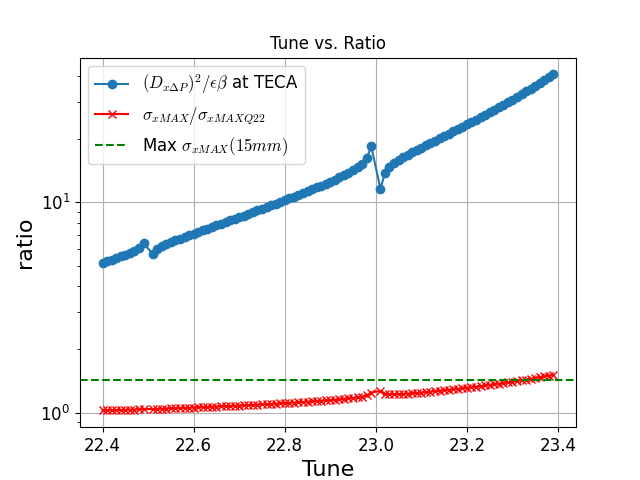

In [26]:
# Calculate the new ratio
#twiss_df['new_ratio'] = (twiss_df['D_xDeltaP']) / twiss_df['EpsilonBeta']

# Plot the data
fig, ax = plt.subplots()
ax.plot(twiss_df['tune'], twiss_df['ratioDxBetaTECA'], marker='o', linestyle='-', label = r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')
ax.plot(twiss_df['tune'], twiss_df['sigma_xMAX'] / sigma_xMAXQ22, marker='x', linestyle='-', color='r', label=r'$\sigma_{xMAX} / \sigma_{xMAXQ22}$')
ax.axhline(0.015 / sigma_xMAXQ22, color='g', linestyle='--', label=r'Max $ \sigma_{xMAX} (15 mm)$')

ax.legend()
ax.set_yscale('log')
ax.set_xlabel('Tune')
ax.set_ylabel(r'ratio')
ax.set_title('Tune vs. Ratio')
ax.grid(True)
plt.show()

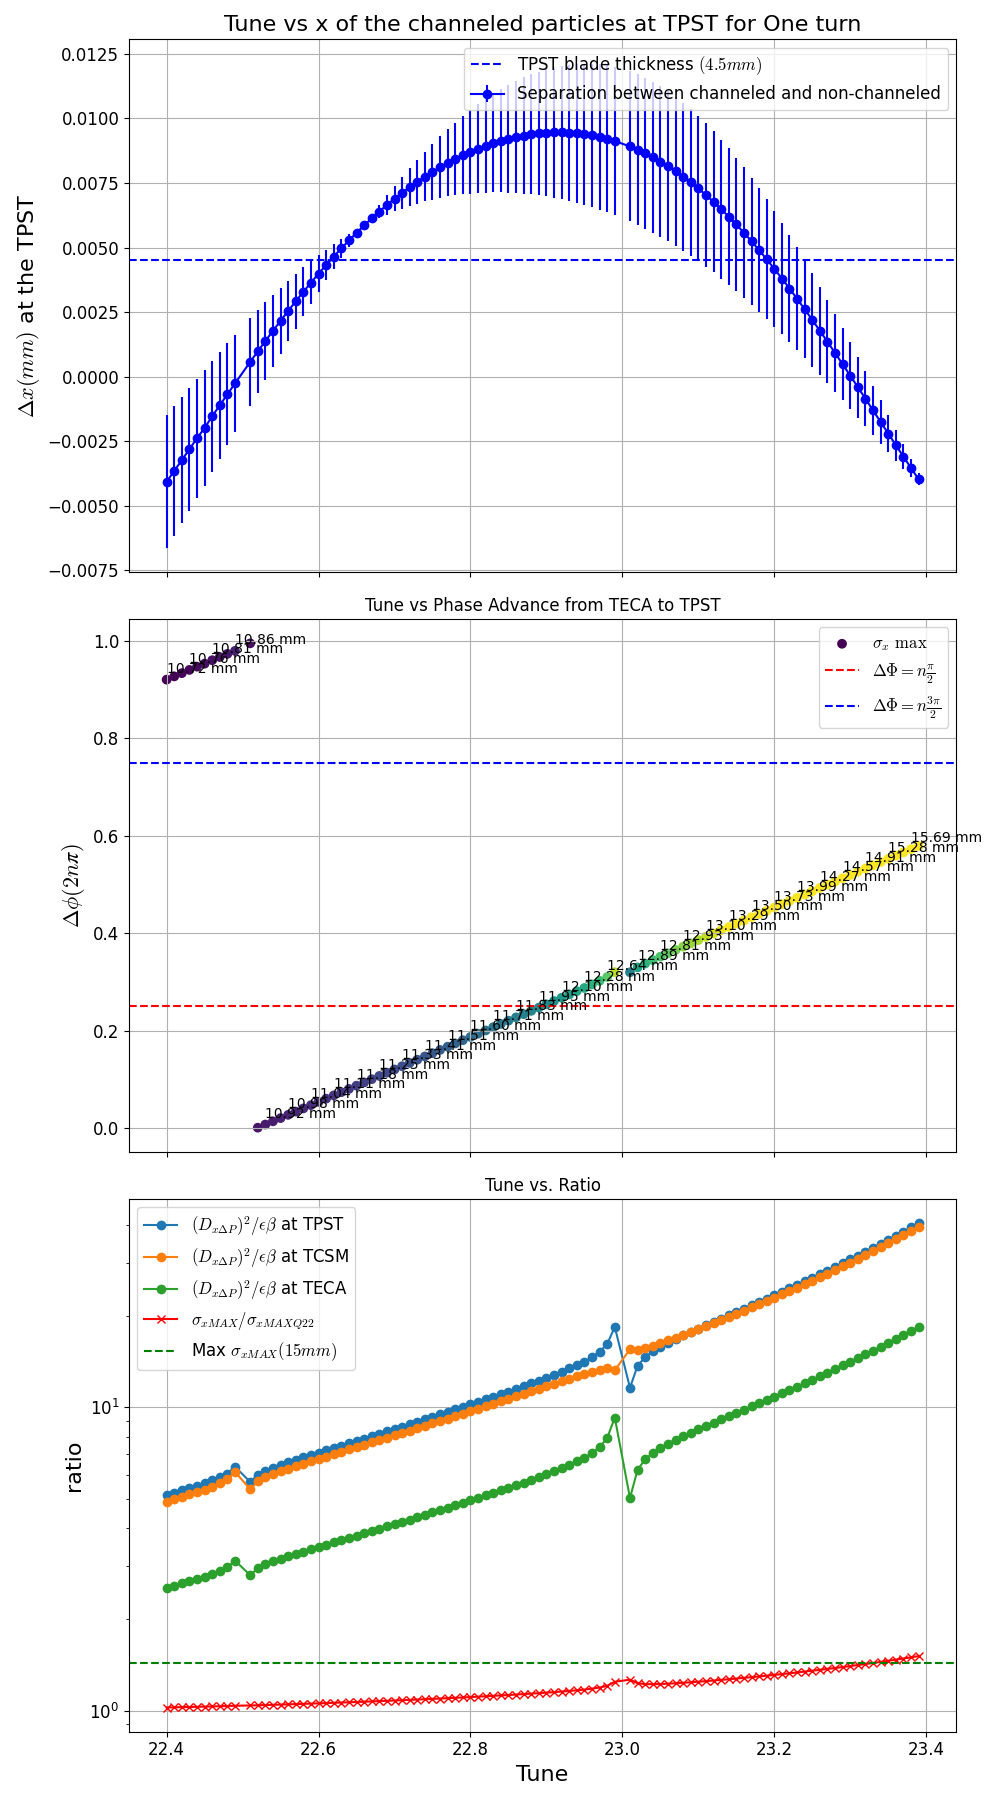

In [27]:
fig, axs = plt.subplots(nrows=3, ncols=1, sharex=True, figsize=(10, 18))

#error = np.abs(twiss_df["ErrorEasyDeltaXtpst"])
# First subplot
#axs[0].errorbar(twiss_df["tune"], twiss_df["x_channeledTPST_negativeMiddle"], yerr=error, color='b', fmt='o', label="Channeled particles")
#axs[0].errorbar(twiss_df["tune"], twiss_df["x_channeledTPST_negativeMiddle"] - twiss_df["EasyDeltaXtpst"], yerr=error, fmt='o', color='y', label=r"Non-Channeled particles ($x_{ch} - \sqrt{\beta_x \beta_{TPST}} \sin(\delta_{\mu_x}) \theta_{TECA}$)")
axs[0].errorbar(twiss_df_Tracking["tune"], twiss_df_Tracking["delta_x_tpst"], yerr = np.abs(twiss_df["ErrorEasyDeltaXtpst"]), color='b', fmt='-o', label="Separation between channeled and non-channeled")
axs[0].axhline(0.0045, color='b', linestyle='--', label=r'TPST blade thickness $ (4.5 mm )$')
axs[0].set_ylabel(r"$\Delta x (mm)$ at the TPST")
axs[0].set_title("Tune vs x of the channeled particles at TPST for One turn")
axs[0].legend()
axs[0].grid()

# Second subplot
sc = axs[1].scatter(twiss_df['tune'], (twiss_df['phaseAdvanceTecaTpst'] % (2 * np.pi)) / (2 * np.pi), c=twiss_df['ratioDxBetaTECA'], cmap='viridis', vmax = 20, label=r'$\sigma_x \text{ max}$')
#cbar = plt.colorbar(sc, ax=axs[1], pad=0.02)
#cbar.set_label(r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')

# Annotate each point with its corresponding sigma_xMAX in mm, but only one every 3 points
for i, row in twiss_df.iterrows():
    if i % 3 == 0:
        sigma_x = row['sigma_xMAX'] * 1000  # Convert to mm
        axs[1].annotate(f'{sigma_x:.2f} mm', (row['tune'], (row['phaseAdvanceTecaTpst'] % (2 * np.pi)) / (2 * np.pi)), textcoords="offset points", xytext=(0, 5), ha='left')

axs[1].set_ylabel(r'$\Delta \phi (2nπ)$')
axs[1].axhline(0.25, color='r', linestyle='--', label=r'$\Delta\Phi = n \frac{\pi}{2}$')
axs[1].axhline(0.75, color='b', linestyle='--', label=r'$\Delta\Phi = n \frac{3\pi}{2}$')
axs[0].title.set_fontsize(16)
axs[1].title.set_fontsize(16)
axs[2].title.set_fontsize(16)
axs[1].set_title('Tune vs Phase Advance from TECA to TPST')
axs[1].grid(True)
axs[1].legend()



# Third subplot
axs[2].plot(twiss_df['tune'], twiss_df['ratioDxBetaTECA'], marker='o', linestyle='-', label=r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TPST')
axs[2].plot(twiss_df['tune'], twiss_df['ratioDxBetaTPST'], marker='o', linestyle='-', label=r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TCSM')
axs[2].plot(twiss_df['tune'], twiss_df['ratioDxBetaTCSM'], marker='o', linestyle='-', label=r'$(D_{x\Delta P})^2 / \epsilon \beta$ at TECA')
axs[2].plot(twiss_df['tune'], twiss_df['sigma_xMAX'] / sigma_xMAXQ22, marker='x', linestyle='-', color='r', label=r'$\sigma_{xMAX} / \sigma_{xMAXQ22}$')
axs[2].axhline(0.015 / sigma_xMAXQ22, color='g', linestyle='--', label=r'Max $ \sigma_{xMAX} (15 mm)$')

axs[2].legend()
axs[2].set_yscale('log')
axs[2].set_xlabel('Tune')
axs[2].set_ylabel(r'ratio')
axs[2].set_title('Tune vs. Ratio')
axs[2].grid(True)

# Ensure the x-axis limits are the same for all subplots
axs[2].set_xlim(axs[0].get_xlim())

plt.tight_layout()
plt.show()


